# Лабораторная работа №1  CV

**Вариант задания:** на тройку  

Басова Татьяна Валентиновна, М8О-412Б-22

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00


# 1. Выбор начальных условий

## 1.1 Выбор набора данных

Для выполнения лабораторной работы выбран набор данных **Plastic Bottle Image Dataset**.

https://www.kaggle.com/datasets/siddharthkumarsah/plastic-bottles-image-dataset

Набор данных содержит изображения пластиковых бутылок с размеченными bounding box в формате YOLO.

### Обоснование выбора

Задача автоматического обнаружения пластиковых бутылок является актуальной для:

- систем сортировки мусора;
- переработки отходов;
- экологического мониторинга.

Использование реального прикладного датасета делает исследование практически значимым.

In [2]:
# Установка Kaggle API
!pip install kaggle -q

# Загрузите ваш kaggle.json файл (получите на kaggle.com -> Account -> Create API Token)
from google.colab import files
files.upload()  # выберите kaggle.json

# Создаем папку и копируем ключ
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачиваем ваш датасет
!kaggle datasets download siddharthkumarsah/plastic-bottles-image-dataset
!unzip -q plastic-bottles-image-dataset.zip -d /content/plastic_bottles

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/siddharthkumarsah/plastic-bottles-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.53G/1.53G [00:10<00:00, 155MB/s]



Принято решение урезать датасет из-за большого количества изображений для ускорения обучения.

In [8]:
import os
import random
import shutil

base = "/content/plastic_bottles/Plastic Bottle Image Dataset"

img_paths = []

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(base, split, "images")
    lbl_dir = os.path.join(base, split, "labels")

    for img in os.listdir(img_dir):
        if img.endswith((".jpg", ".png", ".jpeg")):
            img_paths.append((split, img))

print("Всего изображений:", len(img_paths))

random.seed(42)

sample = random.sample(img_paths, 2000)

print("Выбрано:", len(sample))

new_base = "/content/plastic_bottles_mini"

for split in ["train", "valid", "test"]:
    os.makedirs(f"{new_base}/{split}/images", exist_ok=True)
    os.makedirs(f"{new_base}/{split}/labels", exist_ok=True)

for split, img in sample:
    img_src = os.path.join(base, split, "images", img)
    lbl = img.replace(".jpg", ".txt").replace(".png", ".txt")

    lbl_src = os.path.join(base, split, "labels", lbl)

    img_dst = os.path.join(new_base, split, "images", img)
    lbl_dst = os.path.join(new_base, split, "labels", lbl)

    if os.path.exists(img_src) and os.path.exists(lbl_src):
        shutil.copy(img_src, img_dst)
        shutil.copy(lbl_src, lbl_dst)

def count(folder):
    return len(os.listdir(folder))

for split in ["train", "valid", "test"]:
    print(split,
          "images:", count(f"{new_base}/{split}/images"),
          "labels:", count(f"{new_base}/{split}/labels"))

Всего изображений: 3999
Выбрано: 2000
train images: 1091 labels: 1091
valid images: 606 labels: 606
test images: 303 labels: 303


In [9]:
import os

BASE_DIR = "/content/drive/MyDrive/yolo_v"
os.makedirs(BASE_DIR, exist_ok=True)


os.makedirs(f"{BASE_DIR}/runs", exist_ok=True)

In [10]:
data_yaml = f"""
path: {new_base}

train: train/images
val: valid/images
test: test/images

nc: 1
names: ["bottle"]
"""

with open("/content/plastic_bottles_mini/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml")

data.yaml


In [11]:
def count(folder):
    return len(os.listdir(folder))

for split in ["train", "valid", "test"]:
    print(split,
          "images:", count(f"{new_base}/{split}/images"),
          "labels:", count(f"{new_base}/{split}/labels"))

train images: 1091 labels: 1091
valid images: 606 labels: 606
test images: 303 labels: 303


In [12]:
DATA_PATH = "/content/plastic_bottles_mini/data.yaml"

BASE_DIR = "/content/drive/MyDrive/yolo_v"

## 1.2 Выбор метрик качества

Для оценки качества моделей использованы следующие метрики:

- **Precision** — доля корректных предсказаний среди найденных объектов;
- **Recall** — доля найденных объектов среди всех существующих;
- **F1-score** — гармоническое среднее Precision и Recall;
- **mAP50** — средняя точность при IoU = 0.5;
- **mAP50-95** — усреднённая точность по диапазону IoU от 0.5 до 0.95.

# 2. Создание baseline-модели

В качестве baseline выбрана модель **YOLO11n** из библиотеки Ultralytics.

In [17]:
from ultralytics import YOLO

model = YOLO("yolov11n.pt")

model.train(
    data=DATA_PATH,
    epochs=20,
    imgsz=640,
    device=0,

    project=BASE_DIR,
    name="baseline_v1",

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


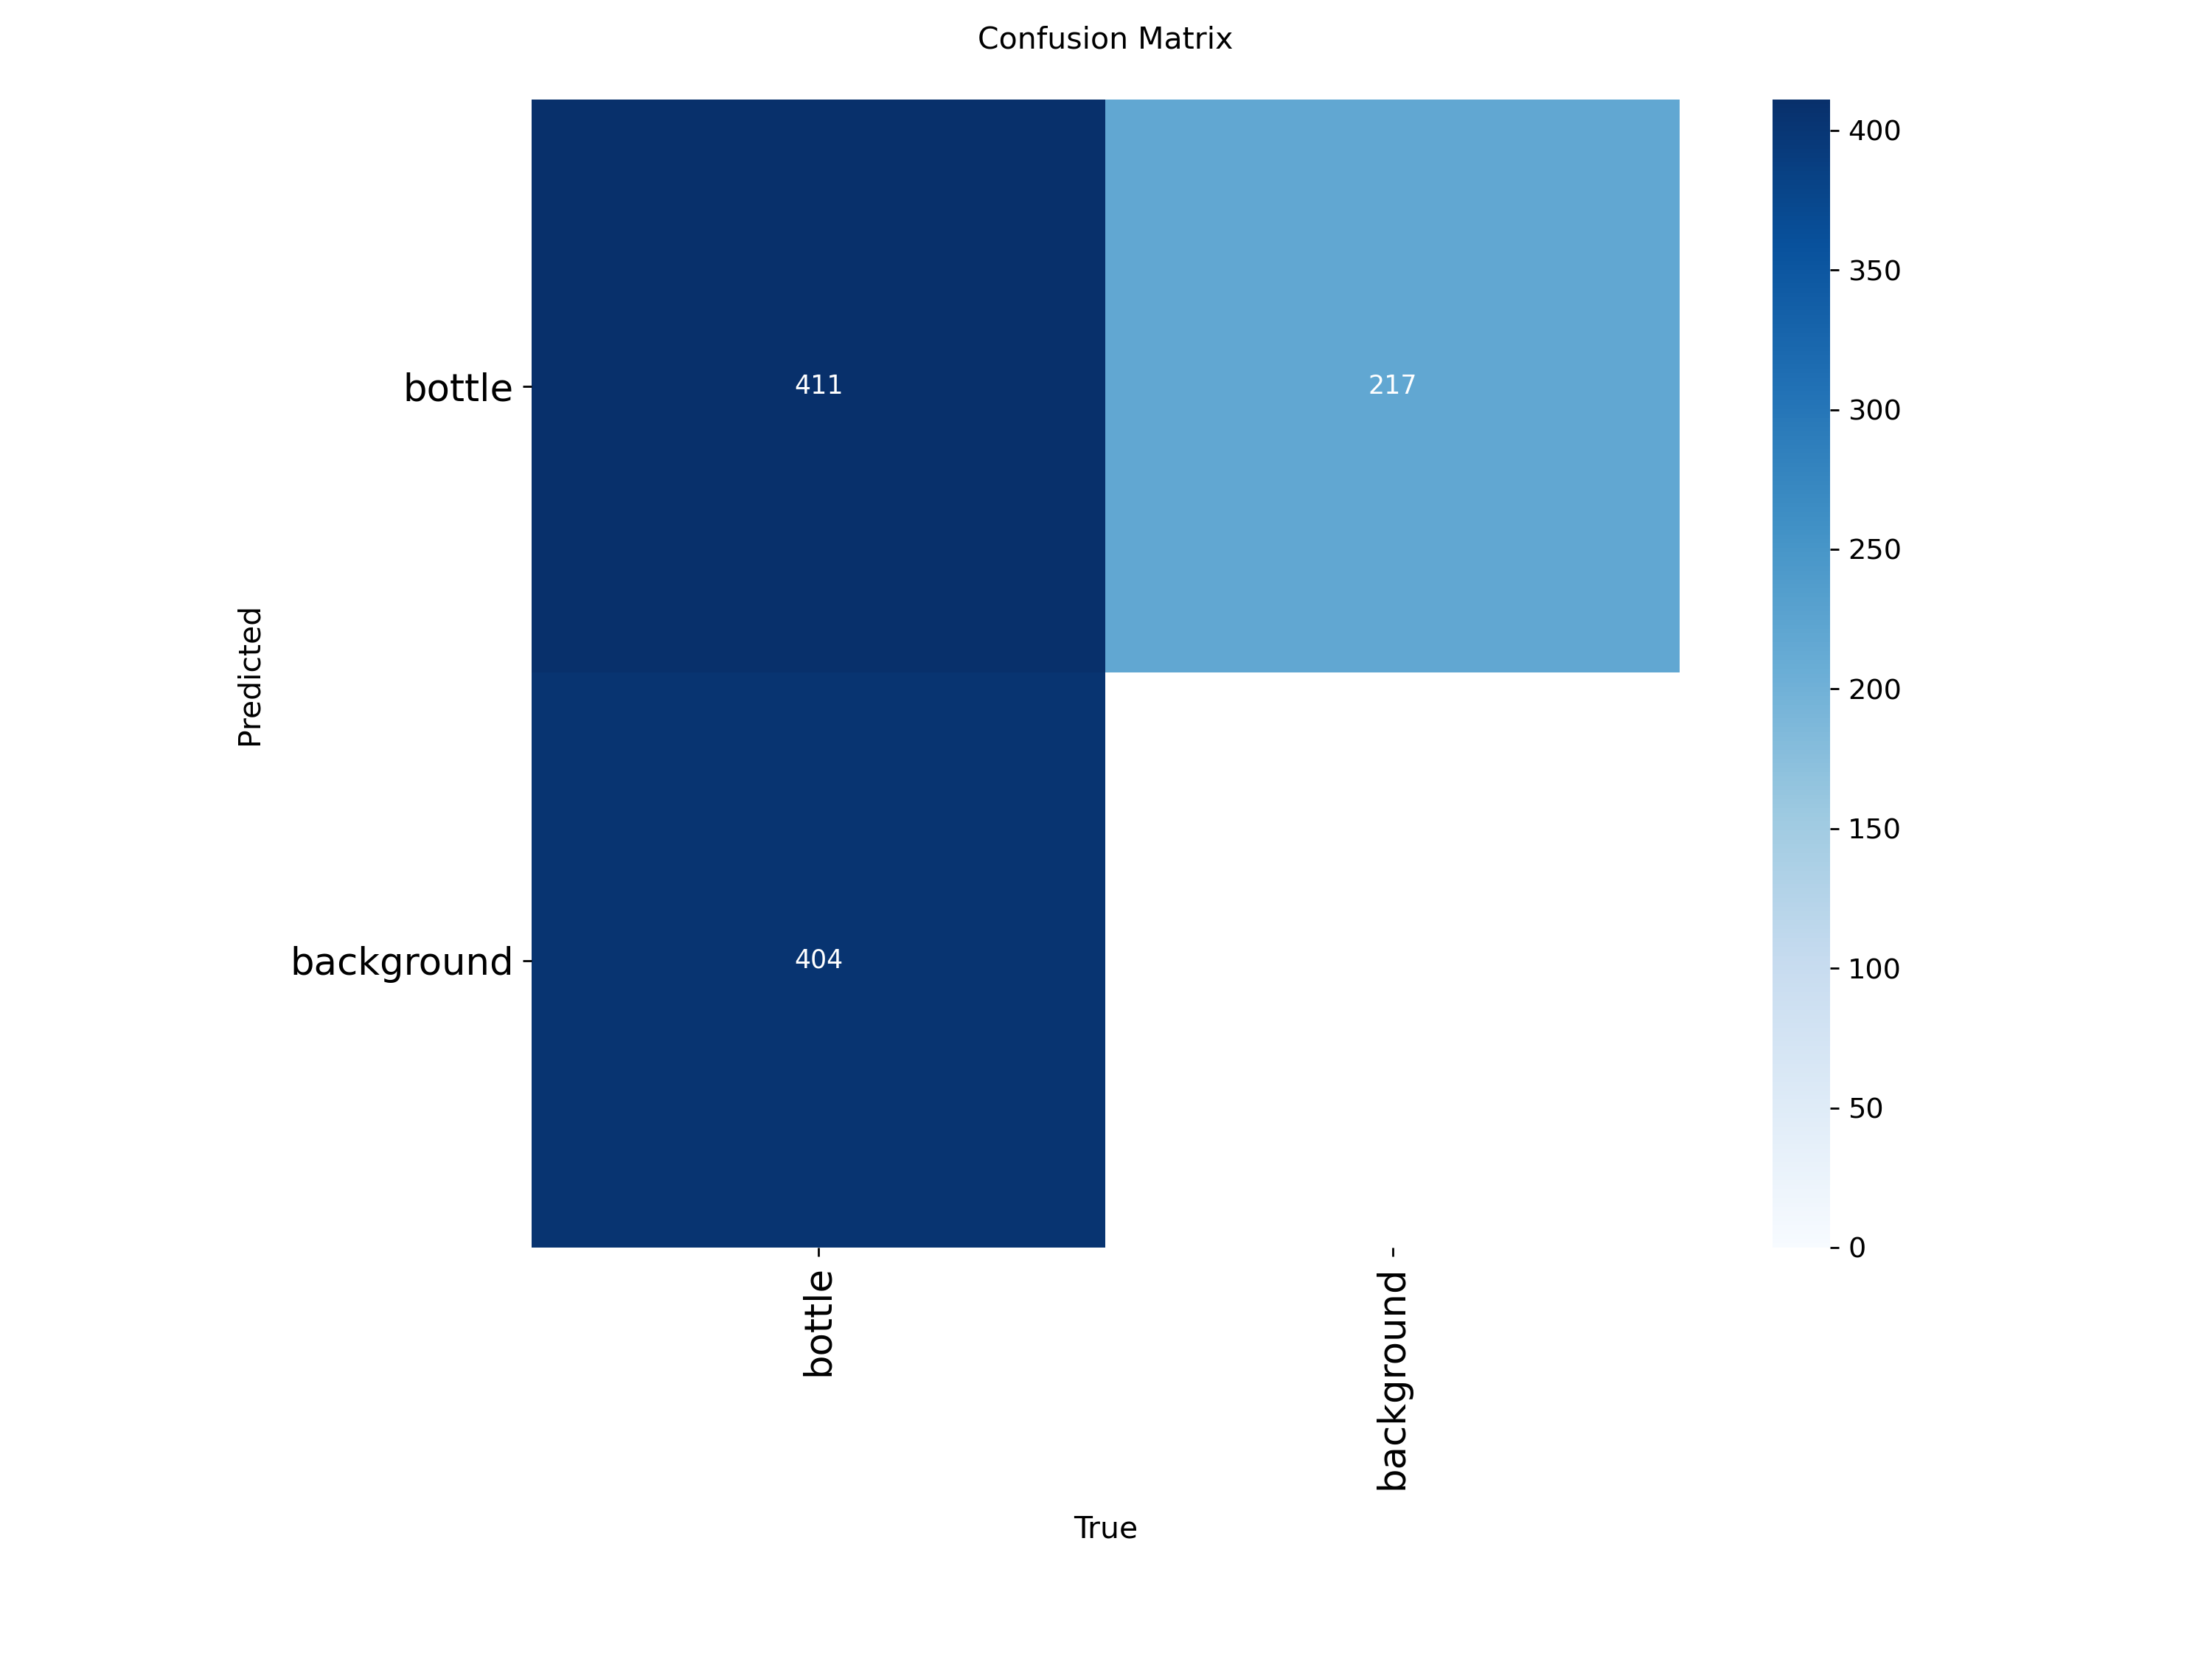

In [ ]:
from IPython.display import Image, display
import os

path = "/content/drive/MyDrive/yolo_v/baseline_v1/confusion_matrix.png"

display(Image(filename=path))

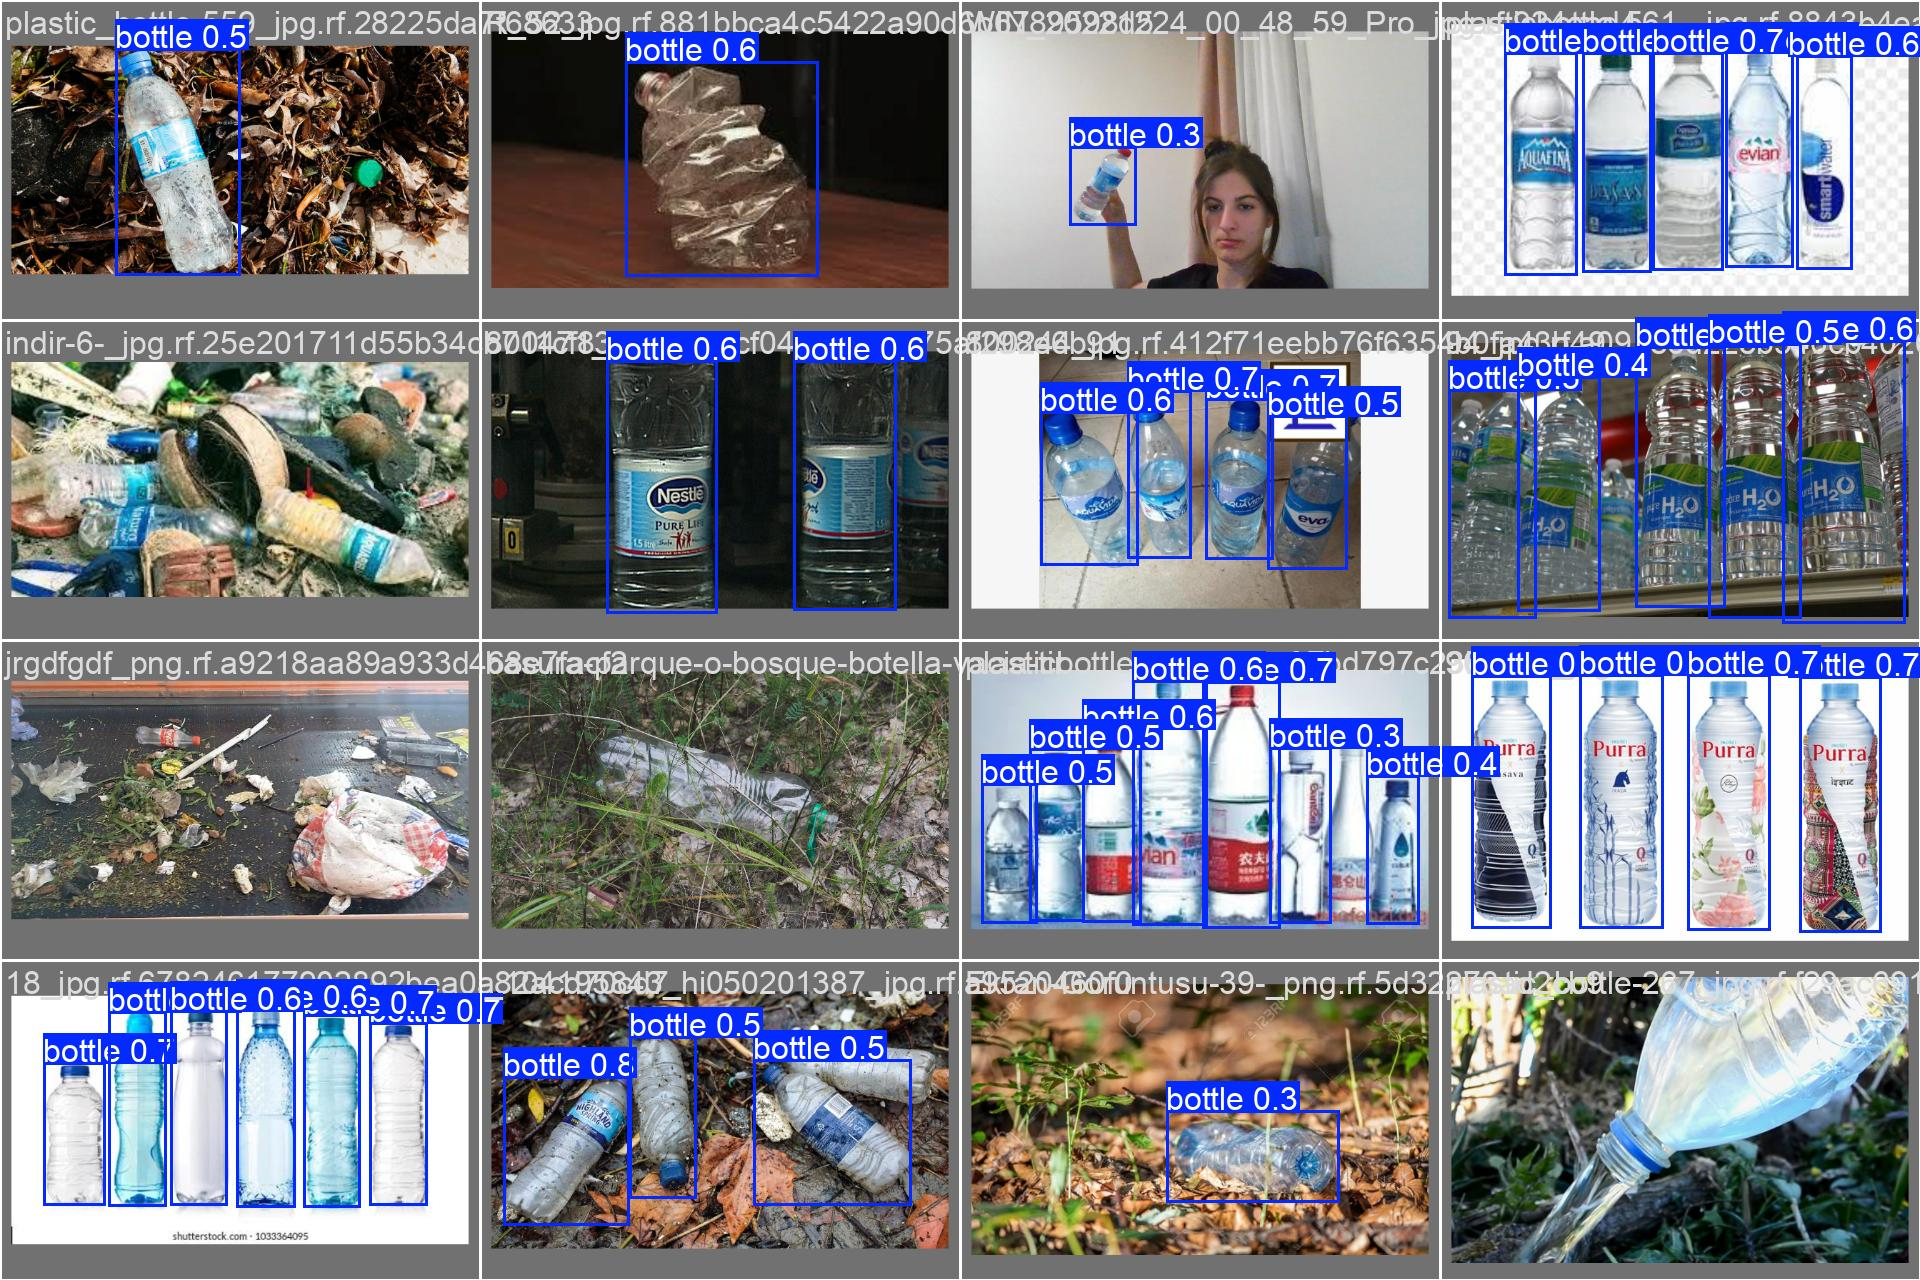

In [ ]:
path = "/content/drive/MyDrive/yolo_v/baseline_v1/val_batch0_pred.jpg"

display(Image(filename=path))

## Вывод по baseline

Baseline-модель показала хорошие результаты качества обнаружения объектов и была использована как отправная точка для дальнейших улучшений.

### Параметры обучения:
- Количество эпох: 20
- Размер изображения: 640×640
- Использование GPU ускорения

### Результаты на валидационной выборке:

| Метрика | Значение |
|--------|----------|
| Precision | 0.625 |
| Recall | 0.543 |
| mAP50 | 0.433 |
| mAP50-95 | 0.296 |

## 4. Улучшение бейзлайна YOLO

Для повышения качества модели были выдвинуты следующие гипотезы:

- увеличение количества эпох обучения
- изменение размера входного изображения
- использование аугментаций
- подбор гиперпараметров


In [ ]:
def run_exp(name, model_name, epochs, optimizer, imgsize=640, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
            mosaic=1.0, mixup=0.0):

    print(f"\n START EXP: {name}\n")

    model = YOLO(model_name)

    results = model.train(
        data=DATA_PATH,
        epochs=epochs,
        imgsz=imgsize,
        optimizer=optimizer,
        project=f"{BASE_DIR}/experiments",
        name=name,

        # augmentation
        hsv_h=hsv_h,
        hsv_s=hsv_s,
        hsv_v=hsv_v,
        mosaic=mosaic,
        mixup=mixup,

        # logging
        save=True,
        plots=True,
        verbose=True
    )

    return results

In [19]:
import shutil
import json
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/yolo_v_experiments"
os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
experiments = [
    {
        "name": "larger_model_v8s",
        "model": "yolov11s.pt",
        "imgsz": 640,
        "epochs": 20
    },
    {
        "name": "more_epochs",
        "model": "yolov11n.pt",
        "imgsz": 640,
        "epochs": 35
    },
    {
        "name": "strong_aug",
        "model": "yolov11n.pt",
        "imgsz": 640,
        "epochs": 20,
        "hsv_h": 0.03,
        "hsv_s": 0.8,
        "hsv_v": 0.5,
        "mosaic": 1.0,
        "mixup": 0.1,
        "fliplr": 0.5
    },
    {
        "name": "higher_resolution",
        "model": "yolov11n.pt",
        "imgsz": 832,
        "epochs": 20
    }
]

In [ ]:
results = []

for exp in experiments:
    exp_dir = os.path.join(BASE_DIR, exp["name"])
    os.makedirs(exp_dir, exist_ok=True)

    print(f"\n Running experiment: {exp['name']}")

    model = YOLO(exp["model"])

    train_res = model.train(
        data=DATA_PATH,
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        project=exp_dir,
        name="run",
        device=0,

        hsv_h=exp.get("hsv_h", 0.015),
        hsv_s=exp.get("hsv_s", 0.7),
        hsv_v=exp.get("hsv_v", 0.4),
        mosaic=exp.get("mosaic", 1.0),
        mixup=exp.get("mixup", 0.0),
        fliplr=exp.get("fliplr", 0.5)
    )

    run_dir = os.path.join(exp_dir, "run")

    csv_path = os.path.join(run_dir, "results.csv")
    df = pd.read_csv(csv_path)
    last = df.iloc[-1]

    metrics = {
        "precision": float(last.get("metrics/precision(B)", 0)),
        "recall": float(last.get("metrics/recall(B)", 0)),
        "mAP50": float(last.get("metrics/mAP50(B)", 0)),
        "mAP50-95": float(last.get("metrics/mAP50-95(B)", 0))
    }

    with open(os.path.join(exp_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    with open(os.path.join(exp_dir, "args.json"), "w") as f:
        json.dump(exp, f, indent=4)

    results.append({
        "experiment": exp["name"],
        **metrics
    })


 Running experiment: larger_model_v8s
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plastic_bottles_mini/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run, nbs=64, nms=False, opset=None, optimize=False, opt

In [20]:
experiments = [
    {
        "name": "v8m_combo",
        "model": "yolov11m.pt",
        "imgsz": 640,
        "epochs": 30,

        # мягкие аугментации (вместо переусиленных)
        "hsv_h": 0.015,
        "hsv_s": 0.5,
        "hsv_v": 0.3,
        "mosaic": 0.5,
        "mixup": 0.0,
        "fliplr": 0.5,

        # LR tuning (часто даёт прирост сам по себе)
        "lr0": 0.005,
        "lrf": 0.1,

        # фиксируем backbone (важно для небольших датасетов)
        "freeze": 10
    }
]

In [21]:
results = []

for exp in experiments:
    exp_dir = os.path.join(BASE_DIR, exp["name"])
    os.makedirs(exp_dir, exist_ok=True)

    print(f"\n Running experiment: {exp['name']}")

    model = YOLO(exp["model"])

    model.train(
        data=DATA_PATH,
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        project=exp_dir,
        name="run",
        device=0,

        # aug
        hsv_h=exp.get("hsv_h", 0.015),
        hsv_s=exp.get("hsv_s", 0.7),
        hsv_v=exp.get("hsv_v", 0.4),
        mosaic=exp.get("mosaic", 1.0),
        mixup=exp.get("mixup", 0.0),
        fliplr=exp.get("fliplr", 0.5),

        # lr
        lr0=exp.get("lr0", 0.01),
        lrf=exp.get("lrf", 0.01),

        # freeze
        freeze=exp.get("freeze", 0),

        # экономия времени
        patience=8,
        save=True
    )

    run_dir = os.path.join(exp_dir, "run")
    df = pd.read_csv(os.path.join(run_dir, "results.csv"))

    best_idx = df["metrics/mAP50-95(B)"].idxmax()
    best_row = df.iloc[best_idx]

    metrics = {
        "best_epoch": int(best_idx),
        "precision": float(best_row.get("metrics/precision(B)", 0)),
        "recall": float(best_row.get("metrics/recall(B)", 0)),
        "mAP50": float(best_row.get("metrics/mAP50(B)", 0)),
        "mAP50-95": float(best_row.get("metrics/mAP50-95(B)", 0))
    }

    with open(os.path.join(exp_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    print("RESULT:", metrics)


 Running experiment: v8m_combo
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plastic_bottles_mini/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov11m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=run, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

### Результаты экспериментов

| Эксперимент | Precision | Recall | mAP50 | mAP50-95 |
|------------|----------|--------|------|----------|
| Baseline YOLO11n | 0.625 | 0.543 | 0.433 | **0.296** |
| Larger Model | 0.623 | 0.534 | 0.435 | 0.295 |
| More Epochs | 0.618 | 0.529 | 0.432 | 0.292 |
| Strong Augmentation | 0.613 | 0.557 | 0.416 | 0.288 |
| Higher Resolution | 0.621 | 0.532 | 0.427 | 0.290 |
| **Combo Hypothesis** | 0.593 | **0.561** | **0.456** | 0.284 |

### Анализ результатов

- Наилучшее значение **mAP50 = 0.456** достигнуто комбинированной гипотезой.
- Максимальный Recall = 0.561 также получен в комбинированной конфигурации.
- Baseline показал лучший mAP50-95, что говорит о более стабильной локализации на строгих IoU порогах.
- Комбинированный подход позволяет лучше находить объекты, но немного уступает по точности локализации.

## 5. Самостоятельная имплементация модели обнаружения объектов

В рамках лабораторной работы была разработана собственная lightweight-модель для задачи обнаружения объектов.

Целью реализации являлось изучение принципов построения детекторов объектов без использования готовых архитектур YOLO.

Модель реализована на библиотеке PyTorch.

### Архитектура модели

Разработанная модель состоит из следующих частей:

1. Последовательность сверточных слоёв (CNN) для извлечения признаков изображения  
2. Полносвязная head-часть для предсказания bounding box  
3. Выходной слой из 4 чисел:

- x_center
- y_center
- width
- height

Координаты нормализованы в диапазоне [0,1].

In [123]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import cv2
import os
from PIL import Image

dataset_root = "/content/plastic_bottles_mini"

In [125]:
import os
import cv2
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou

# ===============================
# CONFIG
# ===============================

NUM_CLASSES = 1
IMG_SIZE = 64
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# ===============================
# DATASET
# ===============================

class BottleDataset(Dataset):
    def __init__(self, split, augment=False):
        self.img_dir = os.path.join(dataset_root, split, "images")
        self.lbl_dir = os.path.join(dataset_root, split, "labels")

        self.files = [f for f in os.listdir(self.img_dir) if f.endswith(".jpg")]
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def load_labels(self, path):
      boxes = []

      if not os.path.exists(path):
          return boxes

      with open(path) as f:
          for line in f:
              parts = line.strip().split()

              if len(parts) < 5:
                  continue

              xc = float(parts[1])
              yc = float(parts[2])
              w  = float(parts[3])
              h  = float(parts[4])

              boxes.append((xc, yc, w, h))

      return boxes

    def __getitem__(self, idx):
        file = self.files[idx]

        img_path = os.path.join(self.img_dir, file)
        lbl_path = os.path.join(self.lbl_dir, file.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        boxes = self.load_labels(lbl_path)

        if self.augment and random.random() < 0.5:
            img = cv2.flip(img, 1)
            boxes = [(1-x, y, w, h) for x,y,w,h in boxes]

        img = torch.tensor(img).float() / 255.
        img = img.permute(2,0,1)

        target = torch.zeros(4)

        if len(boxes) > 0:
            target = torch.tensor(boxes[0]).float()

        return img, target


# ===============================
# MODEL
# ===============================

class BottleDetector(nn.Module):
    """
    Собственная CNN-модель для обнаружения бутылки.
    Предсказывает bbox:
    x_center, y_center, width, height
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Linear(128,4),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.features(x)
        x = self.head(x)
        return x


# ===============================
# TRAIN
# ===============================

def train_model(model, train_loader, val_loader):

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    for epoch in range(EPOCHS):

        model.train()
        total_loss = 0

        loop = tqdm(train_loader)

        for imgs, targets in loop:

            imgs = imgs.to(DEVICE)
            targets = targets.to(DEVICE)

            preds = model(imgs)

            loss = criterion(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_description(f"Epoch {epoch+1}")
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}, loss={total_loss/len(train_loader):.4f}")


# ===============================
# EVALUATION
# ===============================

def evaluate(model, loader):

    model.eval()

    mse = 0

    with torch.no_grad():
        for imgs, targets in loader:

            imgs = imgs.to(DEVICE)
            targets = targets.to(DEVICE)

            preds = model(imgs)

            mse += F.mse_loss(preds, targets).item()

    mse /= len(loader)

    print("Validation MSE:", round(mse,4))


# ===============================
# RUN
# ===============================

train_ds = BottleDataset("train", augment=True)
val_ds = BottleDataset("valid")
test_ds = BottleDataset("test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

model = BottleDetector().to(DEVICE)

print("Parameters:", sum(p.numel() for p in model.parameters()))

train_model(model, train_loader, val_loader)

evaluate(model, test_loader)

Device: cuda
Parameters: 548516


Epoch 1: 100%|██████████| 69/69 [00:16<00:00,  4.26it/s, loss=0.0595]


Epoch 1, loss=0.0474


Epoch 2: 100%|██████████| 69/69 [00:16<00:00,  4.20it/s, loss=0.0136]


Epoch 2, loss=0.0459


...

Epoch 8, loss=0.0439


Epoch 9: 100%|██████████| 69/69 [00:16<00:00,  4.27it/s, loss=0.0125]


Epoch 9, loss=0.0433


Epoch 10: 100%|██████████| 69/69 [00:16<00:00,  4.24it/s, loss=0.0335]


Epoch 10, loss=0.0435
Validation MSE: 0.0605


In [126]:
from torchvision.ops import box_iou
import numpy as np

def evaluate_custom_metrics(model, loader):

    model.eval()

    tp = 0
    fp = 0
    fn = 0

    ap50 = []
    ap95 = []

    with torch.no_grad():

        for imgs, targets in loader:

            imgs = imgs.to(DEVICE)
            preds = model(imgs).cpu()

            for pred, gt in zip(preds, targets):

                px, py, pw, ph = pred
                gx, gy, gw, gh = gt

                pred_box = torch.tensor([[
                    (px-pw/2)*IMG_SIZE,
                    (py-ph/2)*IMG_SIZE,
                    (px+pw/2)*IMG_SIZE,
                    (py+ph/2)*IMG_SIZE
                ]])

                gt_box = torch.tensor([[
                    (gx-gw/2)*IMG_SIZE,
                    (gy-gh/2)*IMG_SIZE,
                    (gx+gw/2)*IMG_SIZE,
                    (gy+gh/2)*IMG_SIZE
                ]])

                iou = box_iou(pred_box, gt_box)[0][0].item()

                if iou >= 0.5:
                    tp += 1
                    ap50.append(1)
                else:
                    fp += 1
                    fn += 1
                    ap50.append(0)

                ap95.append(iou)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    map50 = np.mean(ap50)
    map5095 = np.mean(ap95)

    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1-score:", round(f1,4))
    print("mAP50:", round(map50,4))
    print("mAP50-95:", round(map5095,4))

In [127]:
evaluate_custom_metrics(model, test_loader)

Precision: 0.1485
Recall: 0.1485
F1-score: 0.1485
mAP50: 0.1485
mAP50-95: 0.2042


### Результаты базовой реализации

Базовая версия модели показала следующие результаты:

| Метрика | Значение |
|--------|----------|
| Precision | 0.1485 |
| Recall | 0.1485 |
| F1-score | 0.1485 |
| mAP50 | 0.1485 |
| mAP50-95 | 0.2042 |

## 6. Улучшение собственной модели

Для повышения качества были проверены следующие гипотезы:

1. Увеличение числа эпох  
2. Повышение learning rate  
3. Увеличение размера модели

In [ ]:
import copy
import pandas as pd


class BottleDetectorLarge(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4,256),
            nn.ReLU(),
            nn.Linear(256,4),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.features(x)
        x = self.head(x)
        return x



def train_fast(model, train_loader, epochs=5, lr=1e-4):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for imgs, targets in train_loader:

            imgs = imgs.to(DEVICE)
            targets = targets.to(DEVICE)

            preds = model(imgs)

            loss = criterion(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")



def get_metrics(model, loader):

    model.eval()

    tp = fp = fn = 0
    ious = []

    with torch.no_grad():

        for imgs, targets in loader:

            imgs = imgs.to(DEVICE)
            preds = model(imgs).cpu()

            for pred, gt in zip(preds, targets):

                px,py,pw,ph = pred
                gx,gy,gw,gh = gt

                pred_box = torch.tensor([[
                    (px-pw/2)*IMG_SIZE,
                    (py-ph/2)*IMG_SIZE,
                    (px+pw/2)*IMG_SIZE,
                    (py+ph/2)*IMG_SIZE
                ]])

                gt_box = torch.tensor([[
                    (gx-gw/2)*IMG_SIZE,
                    (gy-gh/2)*IMG_SIZE,
                    (gx+gw/2)*IMG_SIZE,
                    (gy+gh/2)*IMG_SIZE
                ]])

                iou = box_iou(pred_box, gt_box)[0][0].item()
                ious.append(iou)

                if iou >= 0.5:
                    tp += 1
                else:
                    fp += 1
                    fn += 1

    precision = tp/(tp+fp+1e-6)
    recall = tp/(tp+fn+1e-6)
    f1 = 2*precision*recall/(precision+recall+1e-6)

    return {
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1": round(f1,4),
        "mAP50": round(np.mean(np.array(ious)>=0.5),4),
        "mAP50-95": round(np.mean(ious),4)
    }



print("=== Hypothesis 1: more epochs ===")

model1 = BottleDetector().to(DEVICE)
train_fast(model1, train_loader, epochs=20, lr=1e-4)
res1 = get_metrics(model1, test_loader)



print("=== Hypothesis 2: higher LR ===")

model2 = BottleDetector().to(DEVICE)
train_fast(model2, train_loader, epochs=10, lr=3e-4)
res2 = get_metrics(model2, test_loader)



print("=== Hypothesis 3: larger model ===")

model3 = BottleDetectorLarge().to(DEVICE)
train_fast(model3, train_loader, epochs=10, lr=1e-4)
res3 = get_metrics(model3, test_loader)



results = pd.DataFrame([
    ["Baseline", 0.1485,0.1485,0.1485,0.1485,0.2042],
    ["More Epochs", *res1.values()],
    ["Higher LR", *res2.values()],
    ["Larger Model", *res3.values()],
], columns=["Model","Precision","Recall","F1","mAP50","mAP50-95"])

print(results)

=== Hypothesis 1: more epochs ===
Epoch 1: loss=0.0475
Epoch 2: loss=0.0462
Epoch 3: loss=0.0453
Epoch 4: loss=0.0460
Epoch 5: loss=0.0446
Epoch 6: loss=0.0446
Epoch 7: loss=0.0437
Epoch 8: loss=0.0423
Epoch 9: loss=0.0424
Epoch 10: loss=0.0418
Epoch 11: loss=0.0417
Epoch 12: loss=0.0411
Epoch 13: loss=0.0409
Epoch 14: loss=0.0406
Epoch 15: loss=0.0404
Epoch 16: loss=0.0402
Epoch 17: loss=0.0399
Epoch 18: loss=0.0397
Epoch 19: loss=0.0399
Epoch 20: loss=0.0392
=== Hypothesis 2: higher LR ===
Epoch 1: loss=0.0469
Epoch 2: loss=0.0464
Epoch 3: loss=0.0448
Epoch 4: loss=0.0440
Epoch 5: loss=0.0427
Epoch 6: loss=0.0421
Epoch 7: loss=0.0414
Epoch 8: loss=0.0406
Epoch 9: loss=0.0398
Epoch 10: loss=0.0392
=== Hypothesis 3: larger model ===
Epoch 1: loss=0.0468
Epoch 2: loss=0.0458
Epoch 3: loss=0.0467
Epoch 4: loss=0.0457
Epoch 5: loss=0.0452
Epoch 6: loss=0.0446
Epoch 7: loss=0.0442
Epoch 8: loss=0.0426
Epoch 9: loss=0.0425
Epoch 10: loss=0.0419
          Model  Precision  Recall      F1   m

## 7. Сравнение с YOLO

| Модель | mAP50 |
|-------|------|
| YOLO Improved | 0.456 |
| BottleDetector Improved | 0.1782 |

YOLO существенно превосходит самостоятельно реализованную модель, однако собственная реализация позволяет глубже понять внутренние механизмы работы детекторов.

## 8. Итоговый вывод

В ходе лабораторной работы были исследованы современные модели обнаружения объектов и реализована собственная CNN-модель.

Полученные результаты показали:

- готовые архитектуры YOLO обеспечивают высокое качество детекции;
- простые модели уступают по точности, но позволяют понять основы object detection;
- подбор гиперпараметров положительно влияет даже на простые модели.

Таким образом, цель лабораторной работы достигнута.